#Egyptian Real Estate Listings Comprehensive Exploratory Data Analysis and Price Prediction

# **Importing Libraries** <a class="anchor" id="5"></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.stats as stats
import re
from scipy.stats import f_oneway
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# **Loading the Dataset** <a class="anchor" id="5"></a>

In [2]:
from google.colab import files
upload = files.upload()

Saving egypt_real_estate_listings.csv to egypt_real_estate_listings (1).csv


In [3]:
df = pd.read_csv('egypt_real_estate_listings.csv')
df.head(40)

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,https://www.propertyfinder.eg/en/plp/buy/chale...,"8,000,000",OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,31 Aug 2025,Cash,"1,200,000 EGP"
1,https://www.propertyfinder.eg/en/plp/buy/villa...,"25,000,000","For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2 Sep 2025,Cash,"2,100,000 EGP"
2,https://www.propertyfinder.eg/en/plp/buy/chale...,"15,135,000","With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,19 Aug 2025,Cash,"1,513,000 EGP"
3,https://www.propertyfinder.eg/en/plp/buy/apart...,"12,652,000",Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,26 Aug 2025,Installments,"1,260,000 EGP"
4,https://www.propertyfinder.eg/en/plp/buy/villa...,"45,250,000",Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2 Sep 2025,Cash,"2,262,500 EGP"
5,https://www.propertyfinder.eg/en/plp/buy/chale...,"19,760,000",Chalet with Marina and Lake View in The Island...,"Marina 5, Marina, Al Alamein, North Coast",Chalet,"1,356 sqft / 126 sqm",3,2,26 Aug 2025,Installments,"988,000 EGP"
6,https://www.propertyfinder.eg/en/plp/buy/penth...,"9,000,000",Penthouse 4BR for sale with Installments over ...,"The Icon Residence, 5th Settlement Compounds, ...",Penthouse,"2,820 sqft / 262 sqm",4,5,3 Jul 2025,Installments,NaN
7,https://www.propertyfinder.eg/en/plp/buy/villa...,"2,770,000","Stand-alone villa in NYOUM Compound, October\n...","Nyoum October, Northern Expansions, 6 October ...",Villa,"3,983 sqft / 370 sqm",5+ Maid,5,26 Aug 2025,Cash,NaN
8,https://www.propertyfinder.eg/en/plp/buy/twin-...,"13,200,000",**La Vista Ras El Hikma seaview twinhouse - Re...,"La vista Ras El Hikma, Ras Al Hekma, North Coast",Twin House,"2,368 sqft / 220 sqm",3,3,25 Aug 2025,Cash,NaN
9,https://www.propertyfinder.eg/en/plp/buy/duple...,"22,300,000",A 195-square-meter duplex + a 42-square-meter ...,"Azad, 5th Settlement Compounds, The 5th Settle...",Duplex,"2,099 sqft / 195 sqm",3+ Maid,2,7 Aug 2025,Installments,"2,230,000 EGP"


# **Inspecting and Exploring the Dataset** <a class="anchor" id="5"></a>

In [4]:
df.shape

(19924, 11)

The dataset has 19,924 rows/records and 11 columns/features. This means that the sample size is 19924.

In [5]:
df.columns

Index(['url', 'price', 'description', 'location', 'type', 'size', 'bedrooms',
       'bathrooms', 'available_from', 'payment_method', 'down_payment'],
      dtype='object')

The column names in the dataset are clear, descriptive, and simple, which facilitates working with and understanding the dataset. Below is a brief explanation of each column:

`url`: The URL of the property listing on Property Finder.

`price`: The price of the property.

`description`: A detailed textual description of the property.

`location`: The geographic location where the property is situated.

`type`: The type of property, such as an apartment, villa, or chalet.

`size`: The size of the property, typically expressed in square feet or square meters.

`bedrooms`: The number of bedrooms available in the property.

`bathrooms`: The number of bathrooms in the property.

`available_from`: The date from which the property becomes available.

`payment_method`: The payment method available for purchasing the property.

`down_payment`: The required down payment for properties available through installment plans.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19924 entries, 0 to 19923
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   url             19924 non-null  object
 1   price           19385 non-null  object
 2   description     19846 non-null  object
 3   location        19833 non-null  object
 4   type            19847 non-null  object
 5   size            19847 non-null  object
 6   bedrooms        19780 non-null  object
 7   bathrooms       19784 non-null  object
 8   available_from  19261 non-null  object
 9   payment_method  19383 non-null  object
 10  down_payment    5445 non-null   object
dtypes: object(11)
memory usage: 1.7+ MB


In [7]:
df.isnull().sum()

,0
url,0
price,539
description,78
location,91
type,77
size,77
bedrooms,144
bathrooms,140
available_from,663
payment_method,541


The dataset has some quantitative and numerical columns as objects, so each column must have its suitable data type so it can be dealt with easily later.

Another notice is that the `down_payment` column has many null and empty values so we might need to drop it later.

In [8]:
def column_uniques(df): # A simple function that prints out the unique values and their counts in a column
    for col in df.columns:
        print(f"\n--- Column: {col} ---")
        print("Unique values:")
        display(df[col].unique())
        print("Value counts:")
        display(df[col].value_counts(dropna=False))

In [9]:
column_uniques(df[['type']])


--- Column: type ---
Unique values:


array(['Chalet', 'Villa', 'Apartment', 'Penthouse', 'Twin House',
       'Duplex', 'iVilla', 'Townhouse', 'Hotel Apartment', 'Cabin',
       'Bulk Sale Unit', 'Palace', 'Land', 'Whole Building', 'Full Floor',
       'Roof', nan, 'Bungalow'], dtype=object)

Value counts:


,count
type,
Apartment,8355
Chalet,4038
Villa,3570
Townhouse,1335
Twin House,834
Duplex,622
Penthouse,569
iVilla,268
Hotel Apartment,104


The `type` cokumn has 18 unique entries where most of the entries are Appartments, Chalets or Villas. Also, some NaNs are present.

In [10]:
column_uniques(df[['bedrooms']])


--- Column: bedrooms ---
Unique values:


array(['1+ Maid', '4', '2', '3', '7', '5+ Maid', '3+ Maid', '2+ Maid',
       '1', '4+ Maid', '7+ Maid', 'studio', '5', '6+ Maid', nan,
       'studio+ Maid', '7++ Maid', '7+', '6'], dtype=object)

Value counts:


,count
bedrooms,
3,4959
3+ Maid,3737
2,2849
4+ Maid,2126
2+ Maid,1748
4,1126
5+ Maid,786
1,751
1+ Maid,447


The `bedrooms` cokumn has 19 unique entries where most of the entries are 3 bedrooms, 3 bedrooms+maid or 2 bedrooms. Also, some NaNs are present.


In [11]:
column_uniques(df[['bathrooms']])


--- Column: bathrooms ---
Unique values:


array(['1', '4', '2', '7', '5', '3', '6', '7+', nan, 'none', '4.0', '2.0',
       '7.0', '3.0', '1.0', '5.0', '6.0'], dtype=object)

Value counts:


,count
bathrooms,
3,6562
2,5529
4,3281
1,2097
5,1313
6,463
7,223
7+,159
NaN,140


The `bathrooms` cokumn has 17 unique entries where most of the entries are 3 bathrooms, 2 bathrooms or 4 bathrooms. Also, some NaNs are present.

Also, some entires are simialr but written differently. For example, 7 and 7.0.

In [12]:
column_uniques(df[['payment_method']])


--- Column: payment_method ---
Unique values:


array(['Cash', 'Installments', nan], dtype=object)

Value counts:


,count
payment_method,
Cash,15521
Installments,3862
NaN,541


The `payment_method` column has 3 unique values. The unique values are Cash, Installments and some NaNs.

# **Data Cleaninig and Preprocessing** <a class="anchor" id="5"></a>

##1) Useless Variables

###1. The `url` Variable

In [13]:
df = df.drop('url', axis=1)
print("Column 'url' dropped successfully.")

Column 'url' dropped successfully.


The `url` column contains unique identifiers for each listing, which are not relevant for predicting property prices or understanding their characteristics. Therefore, it is appropriate to drop this column to simplify the dataset.

### 2. The `description` Variable

In [14]:
df = df.drop('description', axis=1)
print("Column 'description' dropped successfully.")

Column 'description' dropped successfully.


The `description` column contains detailed textual information about properties. While potentially rich in information, processing natural language text is complex and often requires advanced NLP techniques. For the purpose of simplifying the dataset and focusing on numerical and categorical features for price prediction, I will drop this column.

### 3. The `down_payment` Variable

In [15]:
df = df.drop('down_payment', axis=1)
print("Column 'down_payment' dropped successfully.")

Column 'down_payment' dropped successfully.


The `down_payment` column was dropped because it had a very high number of missing values (14,479 out of 19,924 entries), as identified earlier during the inspection of the dataset. Keeping a column with so many missing values would either require extensive imputation, which could introduce bias, or would make the column largely uninformative for analysis and modeling. Dropping it simplifies the dataset and removes a potentially problematic feature.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19924 entries, 0 to 19923
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   price           19385 non-null  object
 1   location        19833 non-null  object
 2   type            19847 non-null  object
 3   size            19847 non-null  object
 4   bedrooms        19780 non-null  object
 5   bathrooms       19784 non-null  object
 6   available_from  19261 non-null  object
 7   payment_method  19383 non-null  object
dtypes: object(8)
memory usage: 1.2+ MB


##2) Qualitative Variables

### 1. The `type` Variable

In [17]:
column_uniques(df[['type']])


--- Column: type ---
Unique values:


array(['Chalet', 'Villa', 'Apartment', 'Penthouse', 'Twin House',
       'Duplex', 'iVilla', 'Townhouse', 'Hotel Apartment', 'Cabin',
       'Bulk Sale Unit', 'Palace', 'Land', 'Whole Building', 'Full Floor',
       'Roof', nan, 'Bungalow'], dtype=object)

Value counts:


,count
type,
Apartment,8355
Chalet,4038
Villa,3570
Townhouse,1335
Twin House,834
Duplex,622
Penthouse,569
iVilla,268
Hotel Apartment,104


The `type` cokumn has 18 unique entries where most of the entries are Appartments, Chalets or Villas. Also, some NaNs are present.

### Imputing Missing Values in `type`

In [18]:
most_frequent_type = df['type'].mode()[0]
df['type'] = df['type'].fillna(most_frequent_type)
print(f"NaN values in 'type' column filled with '{most_frequent_type}'.")
print("Number of NaNs in 'type' after imputation:", df['type'].isnull().sum())

NaN values in 'type' column filled with 'Apartment'.
Number of NaNs in 'type' after imputation: 0


The NaNs in the variable `type` were filled with the most abundant value which is 'Apartment'.

### Grouping rare values in `type`

In [19]:
type_counts = df["type"].value_counts()
rare_types = type_counts[type_counts < 100].index
df["type"] = df["type"].replace(rare_types, "Other")

In [20]:
df["type"].value_counts()

,count
type,
Apartment,8432
Chalet,4038
Villa,3570
Townhouse,1335
Twin House,834
Duplex,622
Penthouse,569
iVilla,268
Other,152


Now, the `type` column has 10 values with no NaNs present and the rare values grouped into one value named 'Other'.

### Visualizing the `type` variable

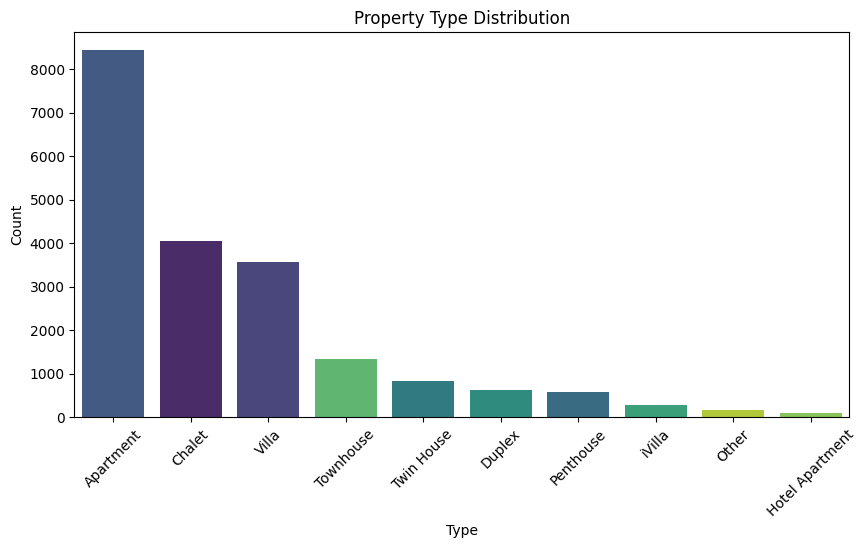

In [21]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="type", order=df["type"].value_counts().index, palette="viridis", hue="type", legend=False)
plt.xticks(rotation=45)
plt.xlabel("Type")
plt.ylabel("Count")
plt.title("Property Type Distribution")
plt.show()

Encoding the `type` Variable Using the One-Hot Encoder

In [22]:
encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded = encoder.fit_transform(df[["type"]])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(["type"]))
df = pd.concat([df.drop("type", axis=1), encoded_df], axis=1)

In [23]:
df.head(20)

,price,location,size,bedrooms,bathrooms,available_from,payment_method,type_Chalet,type_Duplex,type_Hotel Apartment,type_Other,type_Penthouse,type_Townhouse,type_Twin House,type_Villa,type_iVilla
0,"8,000,000","Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",732 sqft / 68 sqm,1+ Maid,1,31 Aug 2025,Cash,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,"25,000,000","Karmell, New Zayed City, Sheikh Zayed City, Giza","2,368 sqft / 220 sqm",4,4,2 Sep 2025,Cash,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,"15,135,000","Azha North, Ras Al Hekma, North Coast","1,270 sqft / 118 sqm",2,2,19 Aug 2025,Cash,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,"12,652,000","Taj City, 5th Settlement Compounds, The 5th Se...","1,787 sqft / 166 sqm",3,2,26 Aug 2025,Installments,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,"45,250,000","Granville, New Capital City, Cairo","4,306 sqft / 400 sqm",7,7,2 Sep 2025,Cash,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,"19,760,000","Marina 5, Marina, Al Alamein, North Coast","1,356 sqft / 126 sqm",3,2,26 Aug 2025,Installments,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,"9,000,000","The Icon Residence, 5th Settlement Compounds, ...","2,820 sqft / 262 sqm",4,5,3 Jul 2025,Installments,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7,"2,770,000","Nyoum October, Northern Expansions, 6 October ...","3,983 sqft / 370 sqm",5+ Maid,5,26 Aug 2025,Cash,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,"13,200,000","La vista Ras El Hikma, Ras Al Hekma, North Coast","2,368 sqft / 220 sqm",3,3,25 Aug 2025,Cash,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,"22,300,000","Azad, 5th Settlement Compounds, The 5th Settle...","2,099 sqft / 195 sqm",3+ Maid,2,7 Aug 2025,Installments,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The `type` variable is categorical, so One-Hot Encoding was used to convert each property type into binary variables (0 or 1), enabling it to be used later in the regression model.

### 2. The `bedrooms` Variable

In [24]:
column_uniques(df[['bedrooms']])


--- Column: bedrooms ---
Unique values:


array(['1+ Maid', '4', '2', '3', '7', '5+ Maid', '3+ Maid', '2+ Maid',
       '1', '4+ Maid', '7+ Maid', 'studio', '5', '6+ Maid', nan,
       'studio+ Maid', '7++ Maid', '7+', '6'], dtype=object)

Value counts:


,count
bedrooms,
3,4959
3+ Maid,3737
2,2849
4+ Maid,2126
2+ Maid,1748
4,1126
5+ Maid,786
1,751
1+ Maid,447


### Imputing Missing Values in `bedrooms`

In [25]:
most_frequent_type = df['bedrooms'].mode()[0]
df['bedrooms'] = df['bedrooms'].fillna(most_frequent_type)
print(f"NaN values in 'bedrooms' column filled with '{most_frequent_type}'.")
print("Number of NaNs in 'bedrooms' after imputation:", df['bedrooms'].isnull().sum())

NaN values in 'bedrooms' column filled with '3'.
Number of NaNs in 'bedrooms' after imputation: 0


The missing values in the `bedrooms` variable were imputed using the mode because it represents the most common bedroom configuration in the dataset. Since the proportion of missing values is very small, this approach preserves the overall distribution without introducing significant bias.

### Dealing with bedrooms with + Maid and adding a `maid_room` binary encoded column.

In [26]:
df['maid_room'] = df['bedrooms'].apply(lambda x: 1 if isinstance(x, str) and 'Maid' in x else 0)
df['bedrooms'] = df['bedrooms'].str.replace(r'\s*\+\s*Maid', '', regex=True)
df['bedrooms'] = df['bedrooms'].str.lower().replace('studio', '1') # Converting to lowercase before replacing 'studio'
df['bedrooms'] = df['bedrooms'].str.replace('7+', '7', regex=False) # Replacing '7+' with '7'
df['bedrooms'] = pd.to_numeric(df['bedrooms'])
print("New 'maid_room' column created and 'bedrooms' column cleaned and converted to numeric.")
print("Unique values in 'bedrooms' after cleaning:", df['bedrooms'].unique())

New 'maid_room' column created and 'bedrooms' column cleaned and converted to numeric.
Unique values in 'bedrooms' after cleaning: [1 4 2 3 7 5 6]


In [27]:
df.head(20)

,price,location,size,bedrooms,bathrooms,available_from,payment_method,type_Chalet,type_Duplex,type_Hotel Apartment,type_Other,type_Penthouse,type_Townhouse,type_Twin House,type_Villa,type_iVilla,maid_room
0,"8,000,000","Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",732 sqft / 68 sqm,1,1,31 Aug 2025,Cash,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,"25,000,000","Karmell, New Zayed City, Sheikh Zayed City, Giza","2,368 sqft / 220 sqm",4,4,2 Sep 2025,Cash,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,"15,135,000","Azha North, Ras Al Hekma, North Coast","1,270 sqft / 118 sqm",2,2,19 Aug 2025,Cash,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,"12,652,000","Taj City, 5th Settlement Compounds, The 5th Se...","1,787 sqft / 166 sqm",3,2,26 Aug 2025,Installments,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,"45,250,000","Granville, New Capital City, Cairo","4,306 sqft / 400 sqm",7,7,2 Sep 2025,Cash,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
5,"19,760,000","Marina 5, Marina, Al Alamein, North Coast","1,356 sqft / 126 sqm",3,2,26 Aug 2025,Installments,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6,"9,000,000","The Icon Residence, 5th Settlement Compounds, ...","2,820 sqft / 262 sqm",4,5,3 Jul 2025,Installments,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
7,"2,770,000","Nyoum October, Northern Expansions, 6 October ...","3,983 sqft / 370 sqm",5,5,26 Aug 2025,Cash,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
8,"13,200,000","La vista Ras El Hikma, Ras Al Hekma, North Coast","2,368 sqft / 220 sqm",3,3,25 Aug 2025,Cash,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
9,"22,300,000","Azad, 5th Settlement Compounds, The 5th Settle...","2,099 sqft / 195 sqm",3,2,7 Aug 2025,Installments,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


### Visualizing the `bedrooms` Variable Distribution

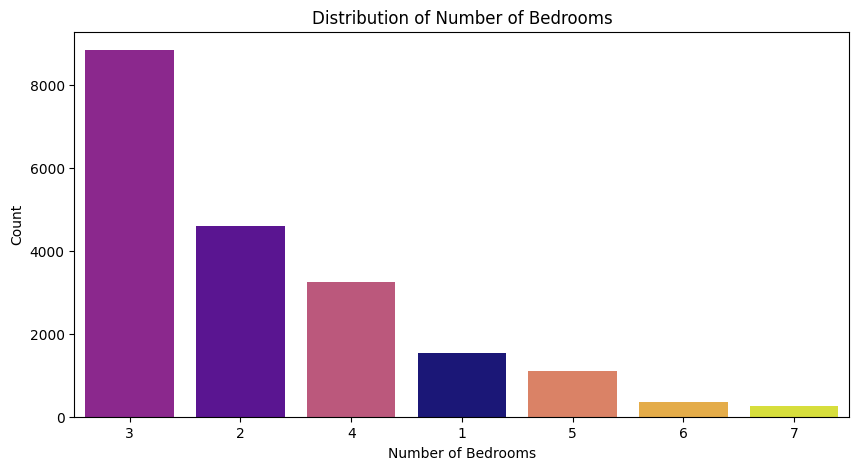

In [28]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="bedrooms", order=df["bedrooms"].value_counts().index, palette="plasma", hue="bedrooms", legend=False)
plt.xlabel("Number of Bedrooms")
plt.ylabel("Count")
plt.title("Distribution of Number of Bedrooms")
plt.show()

The most abundant value of bedrooms is 3 bedrooms followed by 2 bedrooms, this justifies why was the NaN values were imputed with the value 3.

### Visualizing the `maid_room` Variable Proportion

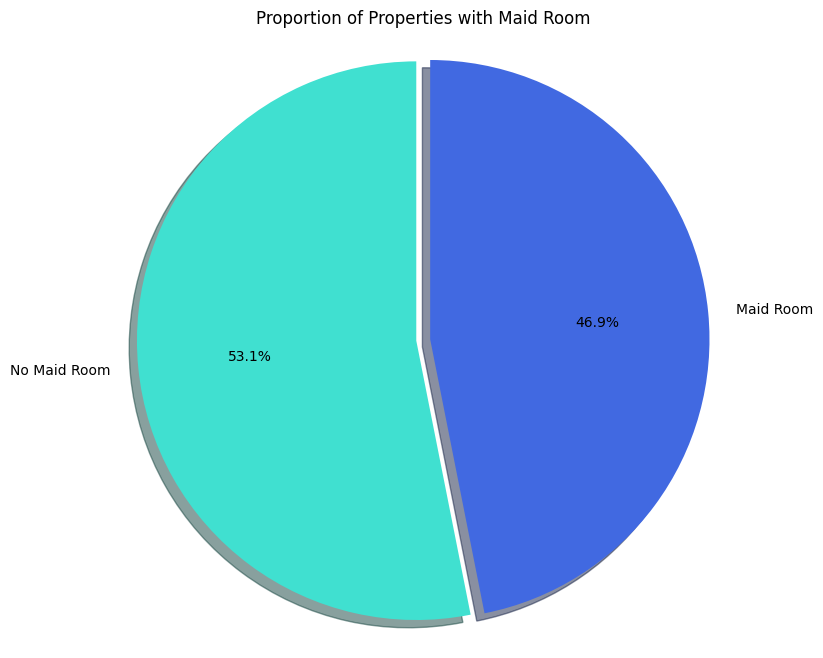

In [29]:
maid_room_counts = df['maid_room'].value_counts()
labels = ['No Maid Room', 'Maid Room']
colors = ['#40E0D0', '#4169E1']
explode = (0.05, 0)

plt.figure(figsize=(8, 8))
plt.pie(maid_room_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=explode, shadow=True)
plt.title('Proportion of Properties with Maid Room')
plt.axis('equal')
plt.show()

This pie chart shows that 53.1% of the property listing has No Maid Rooms While the other 46.9% has Maid Rooms.

### 3. The `bathrooms` Variable

In [30]:
column_uniques(df[['bathrooms']])


--- Column: bathrooms ---
Unique values:


array(['1', '4', '2', '7', '5', '3', '6', '7+', nan, 'none', '4.0', '2.0',
       '7.0', '3.0', '1.0', '5.0', '6.0'], dtype=object)

Value counts:


,count
bathrooms,
3,6562
2,5529
4,3281
1,2097
5,1313
6,463
7,223
7+,159
NaN,140


### Imputing Missing Values in `bathrooms`

In [31]:
most_frequent_bathrooms = df['bathrooms'].mode()[0]
df['bathrooms'] = df['bathrooms'].fillna(most_frequent_bathrooms)
print(f"NaN values in 'bathrooms' column filled with '{most_frequent_bathrooms}'.")
print("Number of NaNs in 'bathrooms' after imputation:", df['bathrooms'].isnull().sum())

NaN values in 'bathrooms' column filled with '3'.
Number of NaNs in 'bathrooms' after imputation: 0


The NaNs in the variable `bathrooms` was imputed and filled with the most abundant number of bathrooms which is 3.

### Fixing Redundant Values Such as 3 and 3.0 and Replacing none with 0.

In [32]:
df['bathrooms'] = df['bathrooms'].astype(str).str.replace('+', '', regex=False)
df['bathrooms'] = df['bathrooms'].str.lower().replace('none', '0')
df['bathrooms'] = pd.to_numeric(df['bathrooms'])

print("Column 'bathrooms' cleaned and converted to numeric.")
print("Unique values in 'bathrooms' after cleaning:", df['bathrooms'].unique())

Column 'bathrooms' cleaned and converted to numeric.
Unique values in 'bathrooms' after cleaning: [1. 4. 2. 7. 5. 3. 6. 0.]


### Visualizing the `bathrooms` Variable Distribution

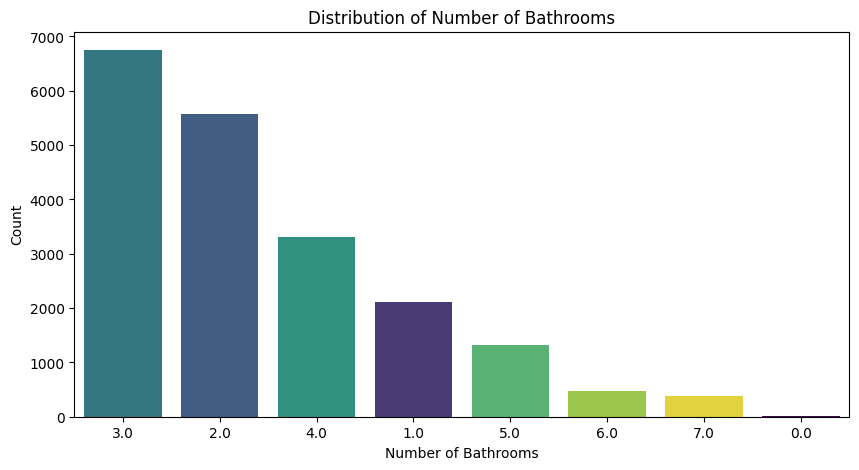

In [33]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="bathrooms", order=df["bathrooms"].value_counts().index, palette="viridis", hue="bathrooms", legend=False)
plt.xlabel("Number of Bathrooms")
plt.ylabel("Count")
plt.title("Distribution of Number of Bathrooms")
plt.show()

The most abundant value of bathrooms is 3 bathrooms followed by 2 bathrooms, this justifies why was the NaN values were imputed with the value 3.

### 4. The `payment_method` Variable

In [34]:
column_uniques(df[['payment_method']])


--- Column: payment_method ---
Unique values:


array(['Cash', 'Installments', nan], dtype=object)

Value counts:


,count
payment_method,
Cash,15521
Installments,3862
NaN,541


### Imputing Missing Values in `payment_method`

In [35]:
# Calculating the proportion of each payment method
payment_method_proportions = df['payment_method'].value_counts(normalize=True)

# Getting the number of missing values
num_missing = df['payment_method'].isnull().sum()

# Creating a list of values to impute, based on proportions
impute_values = np.random.choice(
    payment_method_proportions.index,
    size=num_missing,
    p=payment_method_proportions.values
)

# Imputing missing values
df.loc[df['payment_method'].isnull(), 'payment_method'] = impute_values

print("Missing values in 'payment_method' column imputed proportionally.")
print("Number of NaNs in 'payment_method' after imputation:", df['payment_method'].isnull().sum())
print("Value counts of 'payment_method' after imputation:")
display(df['payment_method'].value_counts())

Missing values in 'payment_method' column imputed proportionally.
Number of NaNs in 'payment_method' after imputation: 0
Value counts of 'payment_method' after imputation:


,count
payment_method,
Cash,15952
Installments,3972


The missing values in the `payment_method` column were imputed proportionally. Instead of filling them with the most frequent value, they were randomly assigned according to the existing distribution of Cash and Installments. This preserves the original distribution of the column and avoids bias toward a single category.

### Label Encoding the `payment_method` Variable

In [36]:
label_encoder = LabelEncoder()
df['payment_method'] = label_encoder.fit_transform(df['payment_method'])
print("Encoded 'payment_method' unique values:", df['payment_method'].unique())
print("Mapping:", list(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
display(df[['payment_method']].head())

Encoded 'payment_method' unique values: [0 1]
Mapping: [('Cash', np.int64(0)), ('Installments', np.int64(1))]


,payment_method
0,0
1,0
2,0
3,1
4,0


In [37]:
print("The 'payment_method' column has been successfully label encoded in place.")
display(df.head())

The 'payment_method' column has been successfully label encoded in place.


,price,location,size,bedrooms,bathrooms,available_from,payment_method,type_Chalet,type_Duplex,type_Hotel Apartment,type_Other,type_Penthouse,type_Townhouse,type_Twin House,type_Villa,type_iVilla,maid_room
0,"8,000,000","Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",732 sqft / 68 sqm,1,1.0,31 Aug 2025,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,"25,000,000","Karmell, New Zayed City, Sheikh Zayed City, Giza","2,368 sqft / 220 sqm",4,4.0,2 Sep 2025,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,"15,135,000","Azha North, Ras Al Hekma, North Coast","1,270 sqft / 118 sqm",2,2.0,19 Aug 2025,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,"12,652,000","Taj City, 5th Settlement Compounds, The 5th Se...","1,787 sqft / 166 sqm",3,2.0,26 Aug 2025,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,"45,250,000","Granville, New Capital City, Cairo","4,306 sqft / 400 sqm",7,7.0,2 Sep 2025,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0


The `payment_method` column has been successfully label encoded. A new column `payment_method_encoded` has been created, with 'Cash' typically mapped to 0 and 'Installments' to 1 (or vice versa, depending on alphabetical order of unique values).

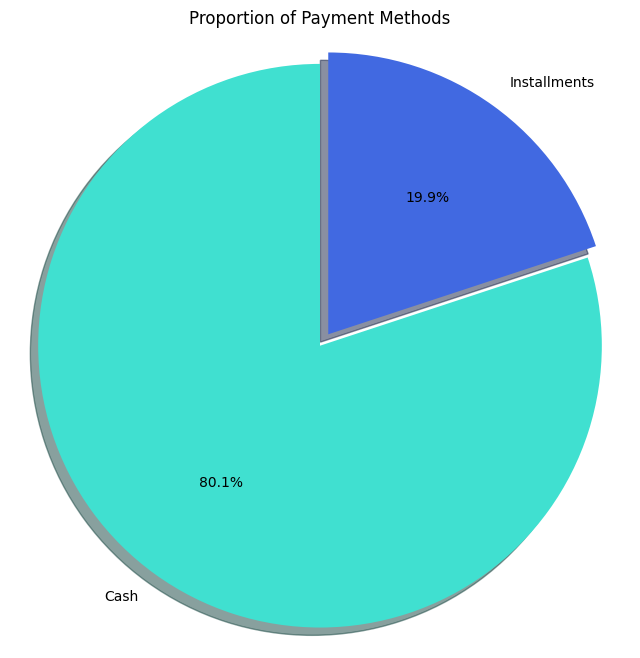

In [38]:
payment_method_counts = df['payment_method'].value_counts()
labels = ['Cash', 'Installments']
colors = ['#40E0D0', '#4169E1']
explode = (0.05, 0)

plt.figure(figsize=(8, 8))
plt.pie(payment_method_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=explode, shadow=True)
plt.title('Proportion of Payment Methods')
plt.axis('equal')
plt.show()

This pie chart shows that 80% of the propertys listed were availabe for sale in Cash while 20% were available for installments.

### 5. The `avaiable_from` Variable

The `available_from` column is a date variable, it should be converted to a proper datetime format and then extract useful features from it. Dates themselves are usually not used directly in regression, but their components can be informative.

### Converting the `available_from` variable to datetimeformat and extracting useful features from it

In [39]:
df["available_from"] = pd.to_datetime(df["available_from"], errors="coerce")
df["available_year"] = df["available_from"].dt.year
df["available_month"] = df["available_from"].dt.month

### Handling Missing Dates

In [40]:
df["available_year"] = df["available_year"].fillna(df["available_year"].mode()[0])
df["available_month"] = df["available_month"].fillna(df["available_month"].mode()[0])

### Dropping the Original `available_from` Column

In [41]:
df = df.drop(columns=["available_from"])

### Inspecting Unique Values in the `available_year` and `available_month` Columns

In [42]:
column_uniques(df[['available_year']])


--- Column: available_year ---
Unique values:


array([2025., 2026., 2024., 2027., 2023.])

Value counts:


,count
available_year,
2025.0,19638
2026.0,187
2024.0,93
2023.0,5
2027.0,1


In [43]:
column_uniques(df[['available_month']])


--- Column: available_month ---
Unique values:


array([ 8.,  9.,  7.,  5., 12.,  4.,  1.,  6., 10.,  2.,  3., 11.])

Value counts:


,count
available_month,
8.0,11204
9.0,6316
7.0,1385
6.0,418
5.0,360
4.0,83
12.0,42
3.0,30
2.0,25


### Visualizing the `available_year` Variable Distribution

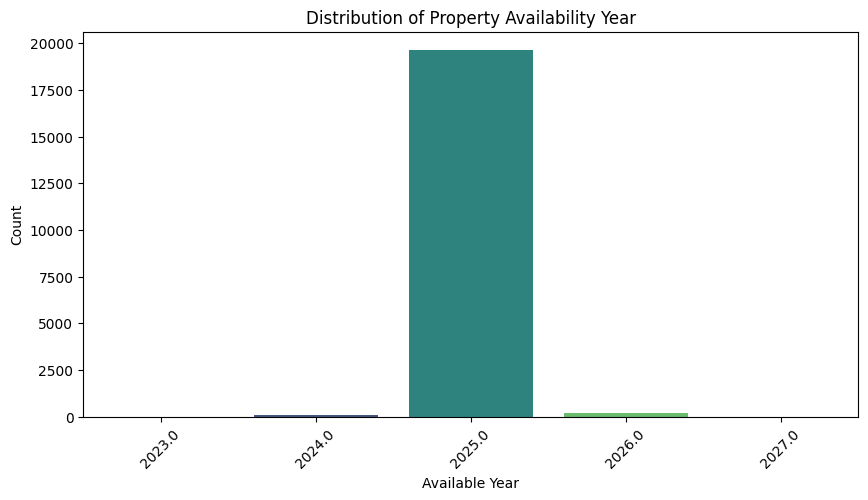

In [44]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="available_year", palette="viridis", hue="available_year", legend=False)
plt.xlabel("Available Year")
plt.ylabel("Count")
plt.title("Distribution of Property Availability Year")
plt.xticks(rotation=45)
plt.show()

This countplot shows that almost all properties in the dataset are available in 2025, with only a very small number in other years. This indicates that the listings are concentrated within a single year, resulting in very low variability. Therefore, this feature provides little useful information for analysis or prediction.

### Visualizing the `available_month` Variable Distribution

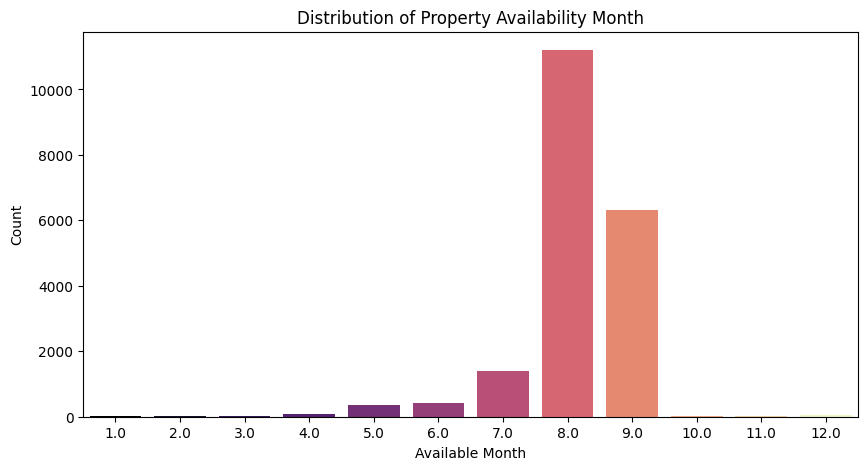

In [45]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="available_month", palette="magma", hue="available_month", legend=False)
plt.xlabel("Available Month")
plt.ylabel("Count")
plt.title("Distribution of Property Availability Month")
plt.show()

This countplot shows that most properties are available starting in August and September, with fewer listings in other months. This indicates that a large proportion of properties in the dataset become available toward the end of summer. However, the uneven distribution suggests that the feature may have limited variability and may not strongly influence the predictive model.

In [46]:
df = df.drop(columns=['available_year', 'available_month'])
print("Columns 'available_year' and 'available_month' dropped successfully.")

Columns 'available_year' and 'available_month' dropped successfully.


In [47]:
df.head(20)

,price,location,size,bedrooms,bathrooms,payment_method,type_Chalet,type_Duplex,type_Hotel Apartment,type_Other,type_Penthouse,type_Townhouse,type_Twin House,type_Villa,type_iVilla,maid_room
0,"8,000,000","Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",732 sqft / 68 sqm,1,1.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,"25,000,000","Karmell, New Zayed City, Sheikh Zayed City, Giza","2,368 sqft / 220 sqm",4,4.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,"15,135,000","Azha North, Ras Al Hekma, North Coast","1,270 sqft / 118 sqm",2,2.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,"12,652,000","Taj City, 5th Settlement Compounds, The 5th Se...","1,787 sqft / 166 sqm",3,2.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,"45,250,000","Granville, New Capital City, Cairo","4,306 sqft / 400 sqm",7,7.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
5,"19,760,000","Marina 5, Marina, Al Alamein, North Coast","1,356 sqft / 126 sqm",3,2.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6,"9,000,000","The Icon Residence, 5th Settlement Compounds, ...","2,820 sqft / 262 sqm",4,5.0,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
7,"2,770,000","Nyoum October, Northern Expansions, 6 October ...","3,983 sqft / 370 sqm",5,5.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
8,"13,200,000","La vista Ras El Hikma, Ras Al Hekma, North Coast","2,368 sqft / 220 sqm",3,3.0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
9,"22,300,000","Azad, 5th Settlement Compounds, The 5th Settle...","2,099 sqft / 195 sqm",3,2.0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


These columns were dropped because they exhibited very low variability. Most listings were concentrated in the year 2025 and the months of August/September. For Linear Regression, features with little to no variance provide minimal predictive power and can sometimes lead to overfitting or unnecessary complexity in the model.

### 3) Quantitative Variables

### 1. The `size` Variable

The `size` variable datatype is an object and it is written in square feet and square meter. It needs to be converted into a numerical datatype alongside choosing the square meter data since it is more familiar and easy to deal with.

In [48]:
def extract_sqm(size_str):
    if pd.isna(size_str):
        return None
    # Using regex to find the numeric value before 'sqm'
    match = re.search(r'([\d,]+)\s*sqm', str(size_str))
    if match:
        # Removing commas and convert to float
        return float(match.group(1).replace(',', ''))
    return None

In [49]:
# Dropping the original size column
df['size_sqm'] = df['size'].apply(extract_sqm)

### Imputing the missing values in `size_sqm` with the median


In [50]:
df['size_sqm'].isna().sum()

np.int64(77)

In [51]:
median_size = df['size_sqm'].median()
df['size_sqm'] = df['size_sqm'].fillna(median_size)

### Dropping the original `size` column

In [52]:
df = df.drop('size', axis=1)
df = df.rename(columns={'size_sqm': 'size'})
print("Column 'size_sqm' renamed to 'size'.")

Column 'size_sqm' renamed to 'size'.


In [53]:
df.head(20)

,price,location,bedrooms,bathrooms,payment_method,type_Chalet,type_Duplex,type_Hotel Apartment,type_Other,type_Penthouse,type_Townhouse,type_Twin House,type_Villa,type_iVilla,maid_room,size
0,"8,000,000","Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",1,1.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,68.0
1,"25,000,000","Karmell, New Zayed City, Sheikh Zayed City, Giza",4,4.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,220.0
2,"15,135,000","Azha North, Ras Al Hekma, North Coast",2,2.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,118.0
3,"12,652,000","Taj City, 5th Settlement Compounds, The 5th Se...",3,2.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,166.0
4,"45,250,000","Granville, New Capital City, Cairo",7,7.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,400.0
5,"19,760,000","Marina 5, Marina, Al Alamein, North Coast",3,2.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,126.0
6,"9,000,000","The Icon Residence, 5th Settlement Compounds, ...",4,5.0,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,262.0
7,"2,770,000","Nyoum October, Northern Expansions, 6 October ...",5,5.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,370.0
8,"13,200,000","La vista Ras El Hikma, Ras Al Hekma, North Coast",3,3.0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,220.0
9,"22,300,000","Azad, 5th Settlement Compounds, The 5th Settle...",3,2.0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,195.0


The `size` variable was originally an object containing both square feet and square meters. We have extracted the numerical square meter value using regular expressions, converted it to a float, and imputed missing values with the median size to ensure it is ready for regression modeling.

### Checking for Outliers in the `size` Variable using a Boxplot

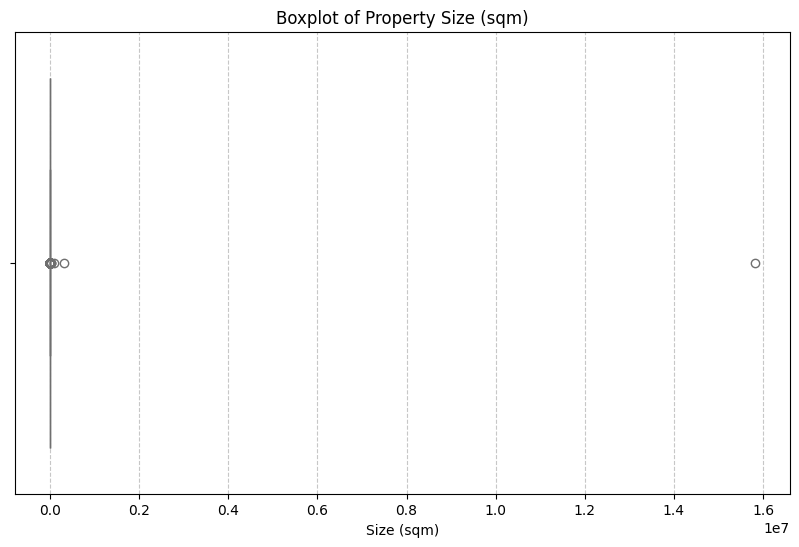

In [54]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['size'], color='skyblue')
plt.title('Boxplot of Property Size (sqm)')
plt.xlabel('Size (sqm)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

A very extreme outlier can be visible here alongside some other outliers after visualizing the box plot, We will use the Censoring(Capping) technique to deal with these outliers so we can save as much information as possible.

### Dealing with Outliers Found in the `size` Variable

In [55]:
lower_bound = df['size'].quantile(0.05)
upper_bound = df['size'].quantile(0.95)
df['size'] = np.where(df['size']>upper_bound,upper_bound, np.where(df['size']<lower_bound,lower_bound,df['size']))

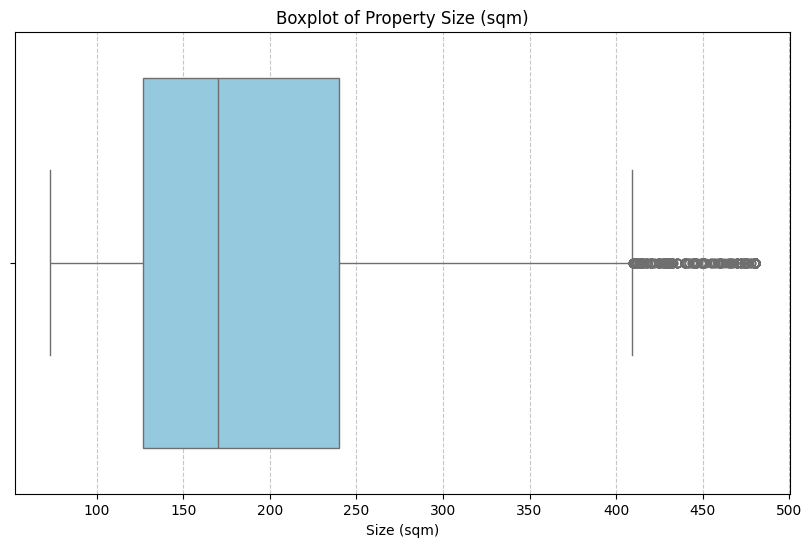

In [56]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['size'], color='skyblue')
plt.title('Boxplot of Property Size (sqm)')
plt.xlabel('Size (sqm)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Now, We have dealt with the extreme outliers, some outliers are still persistent but we are not going to remove them since they are not that extreme.

### Visualizing the `size` Variable Distribution

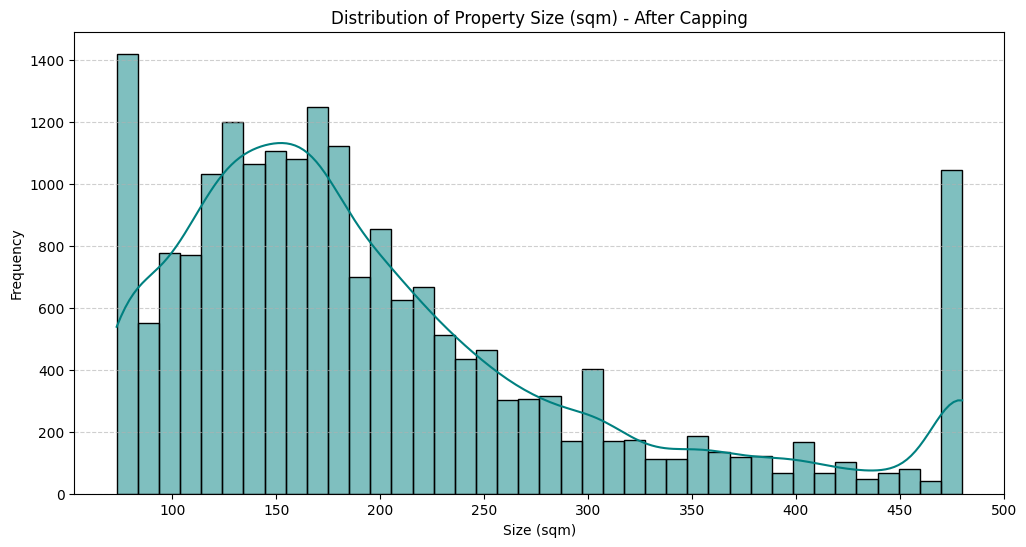

In [57]:
plt.figure(figsize=(12, 6))
sns.histplot(df['size'], kde=True, color='teal', bins=40)
plt.title('Distribution of Property Size (sqm) - After Capping')
plt.xlabel('Size (sqm)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

The distribution of property sizes (in square meters) after capping shows that most properties fall between approximately 120 sqm and 200 sqm, with the highest concentration around 150 sqm. The distribution is right-skewed, meaning there are fewer properties with very large sizes. A small number of larger properties extend toward the upper limit, indicating the presence of larger homes such as villas or duplexes.

## 2. The `price` Variable

### Converting the Price Variable from Object to Float

In [58]:
df['price'] = df['price'].str.replace(',', '').astype(float)
print("Price column type:", df['price'].dtype)

Price column type: float64


### Dropping the missing values in `price`


In [59]:
df = df.dropna(subset=['price'])
print("Number of records after dropping missing prices:", len(df))
display(df['price'].isnull().sum())

Number of records after dropping missing prices: 19385


np.int64(0)

### Checking for Outliers in the `price` Variable using a Boxplot

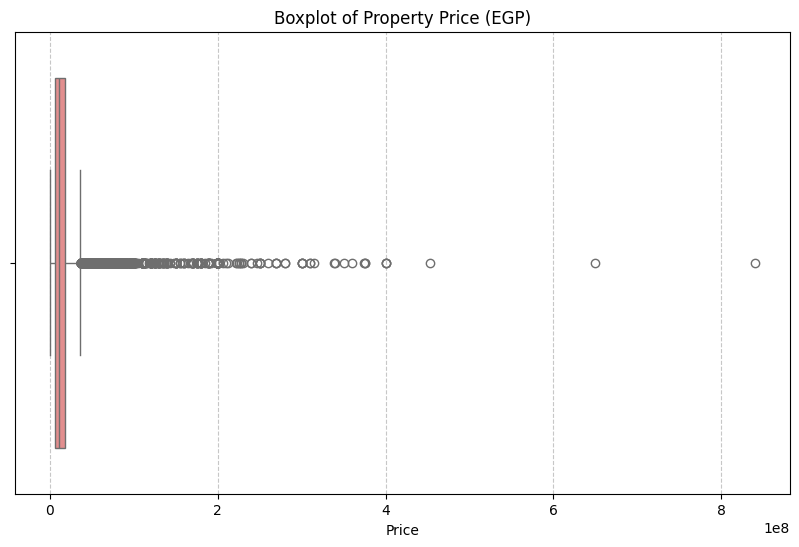

In [60]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['price'], color='lightcoral')
plt.title('Boxplot of Property Price (EGP)')
plt.xlabel('Price')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Dealing with Outliers found in the `price` Variable

In [61]:
lower_bound = df['price'].quantile(0.05)
upper_bound = df['price'].quantile(0.95)
df['price'] = np.where(df['price']>upper_bound,upper_bound, np.where(df['price']<lower_bound,lower_bound,df['price']))

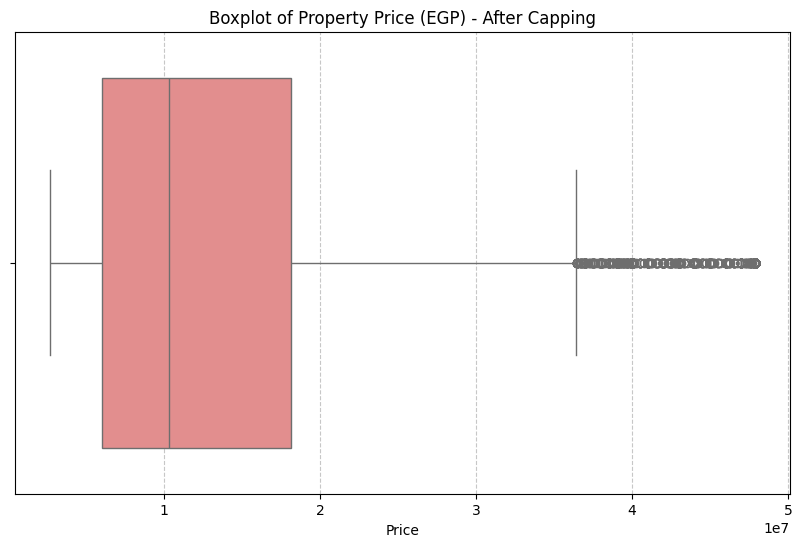

In [62]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['price'], color='lightcoral')
plt.title('Boxplot of Property Price (EGP) - After Capping')
plt.xlabel('Price')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Now, We have dealt with the extreme outliers, some outliers are still persistent but we are not going to remove them since they are not that extreme.

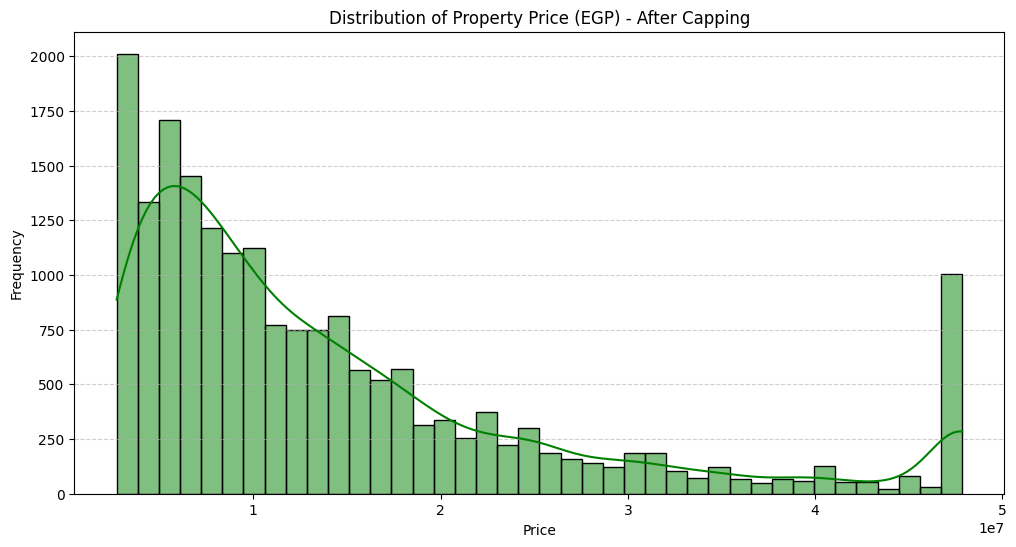

In [63]:
plt.figure(figsize=(12, 6))
sns.histplot(df['price'], kde=True, color='green', bins=40)
plt.title('Distribution of Property Price (EGP) - After Capping')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

The distribution of property prices after capping is right-skewed, indicating that most properties are concentrated at the lower to mid price ranges, while fewer properties exist at very high prices. The majority of listings fall below approximately 2 million EGP, while a small number of higher-priced properties extend toward the upper end of the distribution.

# Inspecting the Dataset After Cleaning and Preprocessing

In [64]:
df.shape

(19385, 16)

We have 19,385 records remaining (down from the initial ~19.9k) after removing rows with missing prices.

In [65]:
df.columns

Index(['price', 'location', 'bedrooms', 'bathrooms', 'payment_method',
       'type_Chalet', 'type_Duplex', 'type_Hotel Apartment', 'type_Other',
       'type_Penthouse', 'type_Townhouse', 'type_Twin House', 'type_Villa',
       'type_iVilla', 'maid_room', 'size'],
      dtype='object')

The dataset now has 16 columns. We've successfully converted categorical variables like `type` into numerical features using One-Hot Encoding and extracted usable numeric values for `size` and `bedrooms`.

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19385 entries, 0 to 19923
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   price                 19385 non-null  float64
 1   location              19385 non-null  object 
 2   bedrooms              19385 non-null  int64  
 3   bathrooms             19385 non-null  float64
 4   payment_method        19385 non-null  int64  
 5   type_Chalet           19385 non-null  float64
 6   type_Duplex           19385 non-null  float64
 7   type_Hotel Apartment  19385 non-null  float64
 8   type_Other            19385 non-null  float64
 9   type_Penthouse        19385 non-null  float64
 10  type_Townhouse        19385 non-null  float64
 11  type_Twin House       19385 non-null  float64
 12  type_Villa            19385 non-null  float64
 13  type_iVilla           19385 non-null  float64
 14  maid_room             19385 non-null  int64  
 15  size                  19

All features are now in numerical formats (float64 or int64), except for the `location` column, which remains as an object for further geospatial or text-based analysis if needed.

In [67]:
df.isnull().sum()

,0
price,0
location,0
bedrooms,0
bathrooms,0
payment_method,0
type_Chalet,0
type_Duplex,0
type_Hotel Apartment,0
type_Other,0
type_Penthouse,0


There are now zero missing values across all remaining columns, ensuring the data is ready for machine learning algorithms such as the liner regression algorithm.

In [68]:
df.describe()

,price,bedrooms,bathrooms,payment_method,type_Chalet,type_Duplex,type_Hotel Apartment,type_Other,type_Penthouse,type_Townhouse,type_Twin House,type_Villa,type_iVilla,maid_room,size
count,1.938500e+04,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000
mean,1.441515e+07,2.972143,2.931493,0.199226,0.204694,0.031571,0.005262,0.007583,0.028888,0.065515,0.041011,0.174826,0.013516,0.464638,198.422984
std,1.185763e+07,1.123074,1.279119,0.399429,0.403489,0.174859,0.072349,0.086753,0.167497,0.247438,0.198321,0.379828,0.115471,0.498761,103.466127
min,2.700000e+06,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,73.150000
25%,6.000000e+06,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000
50%,1.034555e+07,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,170.000000
75%,1.816900e+07,3.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,239.000000
max,4.785250e+07,7.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,480.000000


Both `size` and `price` have been capped at their 5th and 95th percentiles, which reduces the influence of extreme luxury listings and potentially improves model stability.